In [1]:
# Standard imports
import baostock as bs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import sys, os, time

# Import our utilities (assumes utils.py and plot_setup.py are in the same folder)
sys.path.append('.')
from utils import get_stock_data
from plot_setup import setup_chinese_font

setup_chinese_font()
plt.style.use('seaborn-v0_8-whitegrid')

# Reproducibility: fix the random seed so your sample is stable across reruns
np.random.seed(42)

# Sample period — 3 full years covering bear (2022), recovery (2023), mixed (2024)
START_DATE = '2022-01-01'
END_DATE   = '2024-12-31'

Chinese font set to: Microsoft YaHei


In [2]:
import akshare as ak
print(ak.__version__)  # Should print something like 1.14.x or later

1.18.55


In [3]:
# Pull constituent lists from 中证指数公司 via AKShare
# '000300' = 沪深300, '000852' = 中证1000
hs300_df = ak.index_stock_cons_csindex(symbol="000300")
zz1000_df = ak.index_stock_cons_csindex(symbol="000852")

print(f"沪深300: {len(hs300_df)} stocks")
print(f"中证1000: {len(zz1000_df)} stocks")
print("\n沪深300 columns:", hs300_df.columns.tolist())
hs300_df.head()

沪深300: 300 stocks
中证1000: 1000 stocks

沪深300 columns: ['日期', '指数代码', '指数名称', '指数英文名称', '成分券代码', '成分券名称', '成分券英文名称', '交易所', '交易所英文名称']


,日期,指数代码,指数名称,指数英文名称,成分券代码,成分券名称,成分券英文名称,交易所,交易所英文名称
0,2026-04-17,000300,沪深300,CSI 300,000001,平安银行,"Ping An Bank Co., Ltd.",深圳证券交易所,Shenzhen Stock Exchange
1,2026-04-17,000300,沪深300,CSI 300,000002,万科A,China Vanke Co Ltd,深圳证券交易所,Shenzhen Stock Exchange
2,2026-04-17,000300,沪深300,CSI 300,000063,中兴通讯,ZTE Corporation,深圳证券交易所,Shenzhen Stock Exchange
3,2026-04-17,000300,沪深300,CSI 300,000100,TCL科技,TCL Technology Group Corporation,深圳证券交易所,Shenzhen Stock Exchange
4,2026-04-17,000300,沪深300,CSI 300,000157,中联重科,Zoomlion Heavy Industry Science & Technology C...,深圳证券交易所,Shenzhen Stock Exchange


In [4]:
def to_baostock_code(code):
    """Convert bare 6-digit A-share code to baostock format."""
    code = str(code).zfill(6)
    if code.startswith('6'):
        return f'sh.{code}'
    elif code.startswith(('0', '3')):
        return f'sz.{code}'
    elif code.startswith('8') or code.startswith('4'):
        return f'bj.{code}'  # 北交所
    else:
        return None  # unknown, skip
    
# Use the correct column name from your inspection above — adjust if needed
code_col = '成分券代码'  # change this if AKShare uses a different name

hs300_codes_all = hs300_df[code_col].apply(to_baostock_code).dropna().tolist()
zz1000_codes_all = zz1000_df[code_col].apply(to_baostock_code).dropna().tolist()

# Random sample of 25 from each
hs300_sample = list(np.random.choice(hs300_codes_all, size=25, replace=False))
zz1000_sample = list(np.random.choice(zz1000_codes_all, size=25, replace=False))

# Save so we don't re-sample on rerun
os.makedirs('data', exist_ok=True)
pd.Series(hs300_sample).to_csv('data/hs300_sample_codes.csv', index=False, header=['code'])
pd.Series(zz1000_sample).to_csv('data/zz1000_sample_codes.csv', index=False, header=['code'])

print("沪深300 sample (first 5):", hs300_sample[:5])
print("中证1000 sample (first 5):", zz1000_sample[:5])

# Sample bias note: these are the current constituents of 沪深300 and 中证1000 as of today. 
# Stocks that were in either index during 2022-2024 but have since been delisted or removed are not in this sample. (Survivorship bias)
# This means my measured basket returns are biased upward and my measured left tails are thinner than reality. 
# The bias is worse for the 中证1000 sample because small-caps delist and rotate more often. 
# Any conclusion about small-cap tail fatness should be read as a lower bound on the true gap between baskets.

沪深300 sample (first 5): [np.str_('sh.601100'), np.str_('sh.603019'), np.str_('sh.600406'), np.str_('sz.000408'), np.str_('sh.601633')]
中证1000 sample (first 5): [np.str_('sh.600782'), np.str_('sh.600639'), np.str_('sz.300573'), np.str_('sh.688300'), np.str_('sz.301316')]


In [5]:
def load_or_fetch(code, start, end, cache_dir='data/prices'):
    """
    Load a stock's price data from local cache if present; otherwise pull from
    baostock and save. Returns a DataFrame or None if the pull failed / data empty.
    """
    os.makedirs(cache_dir, exist_ok=True)
    # Filename-safe version of the code: 'sh.600519' -> 'sh_600519.csv'
    safe_code = code.replace('.', '_')
    cache_path = os.path.join(cache_dir, f'{safe_code}_{start}_{end}.csv')
    
    if os.path.exists(cache_path):
        df = pd.read_csv(cache_path, index_col='date', parse_dates=True)
        return df if len(df) > 0 else None
    
    try:
        df = get_stock_data(code, start, end, adjustflag='2')  # 前复权
        if df is None or len(df) == 0:
            print(f"  ! {code}: empty")
            return None
        df.to_csv(cache_path)
        return df
    except Exception as e:
        print(f"  ! {code}: {e}")
        return None

def pull_basket(codes, label, start=START_DATE, end=END_DATE):
    """Pull price data for a list of stocks, return a dict {code: DataFrame}."""
    print(f"Pulling {label} ({len(codes)} stocks)...")
    data = {}
    for i, code in enumerate(codes, 1):
        df = load_or_fetch(code, start, end)
        if df is not None:
            data[code] = df
        if i % 5 == 0:
            print(f"  {i}/{len(codes)} done")
        time.sleep(0.1)  # gentle on baostock's server
    print(f"  successfully loaded {len(data)}/{len(codes)}")
    return data

hs300_data = pull_basket(hs300_sample, '沪深300')
zz1000_data = pull_basket(zz1000_sample, '中证1000')

Pulling 沪深300 (25 stocks)...
  5/25 done
  10/25 done
  15/25 done
  20/25 done
  25/25 done
  successfully loaded 25/25
Pulling 中证1000 (25 stocks)...
  5/25 done
  10/25 done
  15/25 done
login success!
logout success!
  20/25 done
  25/25 done
  successfully loaded 25/25


In [6]:
# Check a random stock from each basket
for basket_name, basket_data in [('沪深300', hs300_data), ('中证1000', zz1000_data)]:
    sample_code = list(basket_data.keys())[0]
    df = basket_data[sample_code]
    print(f"\n{basket_name} — {sample_code}")
    print(f"  date range: {df.index.min().date()} to {df.index.max().date()}")
    print(f"  rows: {len(df)}")
    print(f"  missing close prices: {df['close'].isna().sum()}")


沪深300 — sh.601100
  date range: 2022-01-04 to 2024-12-31
  rows: 726
  missing close prices: 0

中证1000 — sh.600782
  date range: 2022-01-04 to 2024-12-31
  rows: 726
  missing close prices: 0


In [7]:
expected_days = 726  # rough — three years of A-share trading days

print("沪深300 row counts:")
for code, df in hs300_data.items():
    if len(df) < expected_days - 30:  # flag anyone missing more than ~30 days
        print(f"  {code}: {len(df)} rows")

print("\n中证1000 row counts:")
for code, df in zz1000_data.items():
    if len(df) < expected_days - 30:
        print(f"  {code}: {len(df)} rows")

沪深300 row counts:

中证1000 row counts:
  sz.301316: 541 rows
  sh.688403: 575 rows
  sz.301511: 333 rows
  sz.301238: 619 rows
  sh.688372: 532 rows
  sh.688502: 442 rows
  sh.688351: 566 rows


In [8]:
flagged = ['sz.301316', 'sh.688403', 'sz.301511', 'sz.301238', 
           'sh.688372', 'sh.688502', 'sh.688351']

for code in flagged:
    if code in zz1000_data:
        df = zz1000_data[code]
        print(f"{code}: first trade {df.index.min().date()}, "
              f"last trade {df.index.max().date()}, rows {len(df)}")

sz.301316: first trade 2022-10-13, last trade 2024-12-31, rows 541
sh.688403: first trade 2022-08-18, last trade 2024-12-31, rows 575
sz.301511: first trade 2023-08-17, last trade 2024-12-31, rows 333
sz.301238: first trade 2022-06-17, last trade 2024-12-31, rows 619
sh.688372: first trade 2022-10-26, last trade 2024-12-31, rows 532
sh.688502: first trade 2023-03-09, last trade 2024-12-31, rows 442
sh.688351: first trade 2022-08-31, last trade 2024-12-31, rows 566


In [9]:
# Find stocks with complete (or near-complete) data throughout the sample
def filter_full_history(basket_data, min_start='2022-01-15'):
    cutoff = pd.Timestamp(min_start)
    full = {code: df for code, df in basket_data.items() 
            if df.index.min() <= cutoff}
    dropped = set(basket_data.keys()) - set(full.keys())
    return full, dropped

hs300_data_full, hs300_dropped = filter_full_history(hs300_data)
zz1000_data_full, zz1000_dropped = filter_full_history(zz1000_data)

print(f"沪深300: kept {len(hs300_data_full)}, dropped {len(hs300_dropped)}")
if hs300_dropped:
    print(f"  dropped: {hs300_dropped}")
print(f"中证1000: kept {len(zz1000_data_full)}, dropped {len(zz1000_dropped)}")
if zz1000_dropped:
    print(f"  dropped: {zz1000_dropped}")

沪深300: kept 25, dropped 0
中证1000: kept 18, dropped 7
  dropped: {np.str_('sz.301511'), np.str_('sh.688403'), np.str_('sz.301238'), np.str_('sh.688502'), np.str_('sh.688372'), np.str_('sh.688351'), np.str_('sz.301316')}


In [10]:
def build_returns_matrix(basket_data):
    """
    Convert {code: OHLCV DataFrame} to a single wide DataFrame of daily returns,
    with dates as index and stock codes as columns.
    """
    # Step 1: extract just the close price from each stock, rename the column to the code
    close_series = {code: df['close'] for code, df in basket_data.items()}
    
    # Step 2: concat along columns — pandas aligns on the date index automatically
    closes = pd.DataFrame(close_series)
    
    # Step 3: compute simple returns. NaN propagates correctly through .pct_change()
    returns = closes.pct_change()
    
    return returns

hs300_returns = build_returns_matrix(hs300_data)
zz1000_returns = build_returns_matrix(zz1000_data)

print(f"沪深300 returns matrix: {hs300_returns.shape}")   
print(f"中证1000 returns matrix: {zz1000_returns.shape}")  

# Inspect a small slice
hs300_returns.iloc[:5, :5]

hs300_returns = build_returns_matrix(hs300_data_full)
zz1000_returns = build_returns_matrix(zz1000_data_full)

hs300_basket = hs300_returns.mean(axis=1).dropna()
zz1000_basket = zz1000_returns.mean(axis=1).dropna()

print(f"沪深300 returns matrix: {hs300_returns.shape}")
print(f"中证1000 returns matrix: {zz1000_returns.shape}")
print(f"沪深300 basket: {len(hs300_basket)} daily returns")
print(f"中证1000 basket: {len(zz1000_basket)} daily returns")

print(f"\nMean daily return (annualized ≈ ×242):")
print(f"  沪深300:  {hs300_basket.mean():.5f} ({hs300_basket.mean()*242:.2%} annualized)")
print(f"  中证1000: {zz1000_basket.mean():.5f} ({zz1000_basket.mean()*242:.2%} annualized)")

沪深300 returns matrix: (726, 25)
中证1000 returns matrix: (726, 25)
沪深300 returns matrix: (726, 25)
中证1000 returns matrix: (726, 18)
沪深300 basket: 725 daily returns
中证1000 basket: 725 daily returns

Mean daily return (annualized ≈ ×242):
  沪深300:  0.00038 (9.09% annualized)
  中证1000: 0.00034 (8.21% annualized)


In [11]:
print("Same date range:", hs300_basket.index.equals(zz1000_basket.index))

Same date range: True


In [12]:
def describe_basket(returns, label):
    """Compute key distribution statistics for a return series."""
    daily_std = returns.std()
    ann_std = daily_std * np.sqrt(242)
    skew = returns.skew()
    kurt = returns.kurtosis()  # pandas reports EXCESS kurtosis (normal = 0)
    
    print(f"\n{label}")
    print(f"  N observations:    {len(returns)}")
    print(f"  Daily mean:        {returns.mean():.5f}")
    print(f"  Daily std:         {daily_std:.5f}")
    print(f"  Annualized std:    {ann_std:.2%}")
    print(f"  Skewness:          {skew:.3f}")
    print(f"  Excess kurtosis:   {kurt:.3f}")
    print(f"  Min:               {returns.min():.4f}  on {returns.idxmin().date()}")
    print(f"  Max:               {returns.max():.4f}  on {returns.idxmax().date()}")
    
    return {'std': daily_std, 'ann_std': ann_std, 
            'skew': skew, 'kurt': kurt,
            'min': returns.min(), 'max': returns.max()}

hs300_stats = describe_basket(hs300_basket, '沪深300 basket')
zz1000_stats = describe_basket(zz1000_basket, '中证1000 basket')


沪深300 basket
  N observations:    725
  Daily mean:        0.00038
  Daily std:         0.01148
  Annualized std:    17.86%
  Skewness:          1.066
  Excess kurtosis:   9.923
  Min:               -0.0556  on 2024-10-09
  Max:               0.0947  on 2024-09-30

中证1000 basket
  N observations:    725
  Daily mean:        0.00034
  Daily std:         0.01595
  Annualized std:    24.82%
  Skewness:          0.091
  Excess kurtosis:   5.532
  Min:               -0.0903  on 2024-10-09
  Max:               0.1069  on 2024-09-30


In [13]:
# Top 5 best and worst days for each basket
print("沪深300 — 5 worst days:")
print(hs300_basket.nsmallest(5))
print("\n沪深300 — 5 best days:")
print(hs300_basket.nlargest(5))
print("\n中证1000 — 5 worst days:")
print(zz1000_basket.nsmallest(5))
print("\n中证1000 — 5 best days:")
print(zz1000_basket.nlargest(5))

沪深300 — 5 worst days:
date
2024-10-09   -0.055631
2022-04-25   -0.048441
2022-03-15   -0.043387
2024-11-22   -0.035524
2024-10-11   -0.031034
dtype: float64

沪深300 — 5 best days:
date
2024-09-30    0.094657
2024-10-08    0.069606
2024-09-27    0.048216
2024-09-24    0.042990
2024-02-06    0.041545
dtype: float64

中证1000 — 5 worst days:
date
2024-10-09   -0.090290
2022-04-25   -0.067052
2024-02-05   -0.064939
2024-01-22   -0.049190
2022-05-24   -0.048735
dtype: float64

中证1000 — 5 best days:
date
2024-09-30    0.106932
2024-10-08    0.074287
2024-04-17    0.049003
2024-02-06    0.048732
2024-09-27    0.048697
dtype: float64


In [14]:
stimulus_start = pd.Timestamp('2024-09-24')
stimulus_end = pd.Timestamp('2024-10-10')

hs300_ex = hs300_basket[(hs300_basket.index < stimulus_start) | 
                        (hs300_basket.index > stimulus_end)]
zz1000_ex = zz1000_basket[(zz1000_basket.index < stimulus_start) | 
                          (zz1000_basket.index > stimulus_end)]

print(f"Dropped {len(hs300_basket) - len(hs300_ex)} days")
_ = describe_basket(hs300_ex, '沪深300 ex-stimulus')
_ = describe_basket(zz1000_ex, '中证1000 ex-stimulus')

Dropped 8 days

沪深300 ex-stimulus
  N observations:    717
  Daily mean:        0.00003
  Daily std:         0.01009
  Annualized std:    15.70%
  Skewness:          0.016
  Excess kurtosis:   2.305
  Min:               -0.0484  on 2022-04-25
  Max:               0.0415  on 2024-02-06

中证1000 ex-stimulus
  N observations:    717
  Daily mean:        0.00001
  Daily std:         0.01460
  Annualized std:    22.72%
  Skewness:          -0.334
  Excess kurtosis:   1.841
  Min:               -0.0671  on 2022-04-25
  Max:               0.0490  on 2024-04-17


Chinese font set to: Microsoft YaHei


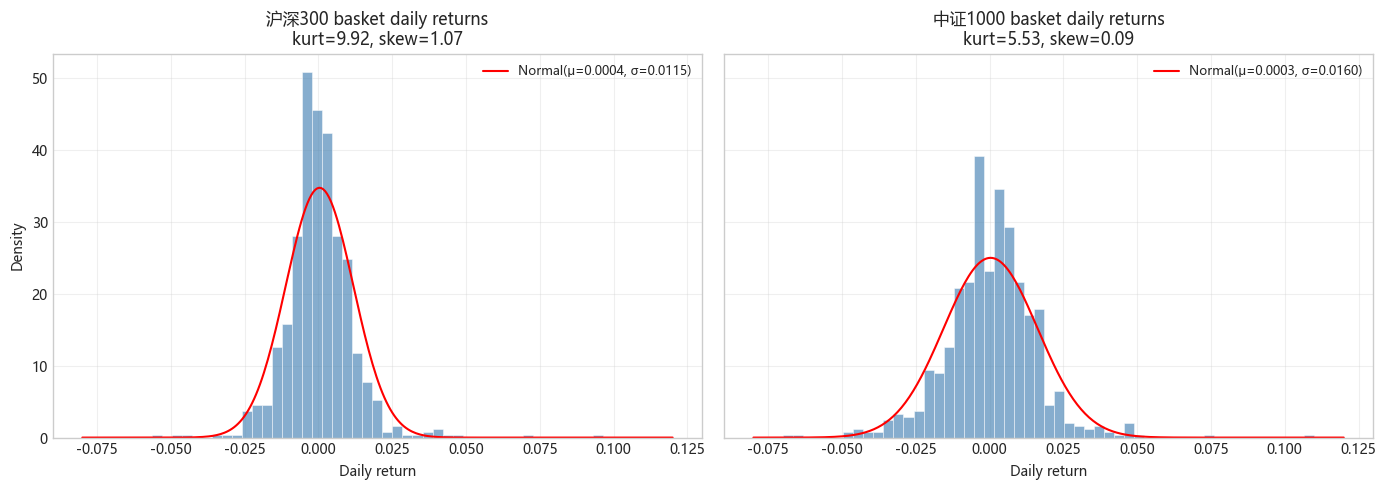

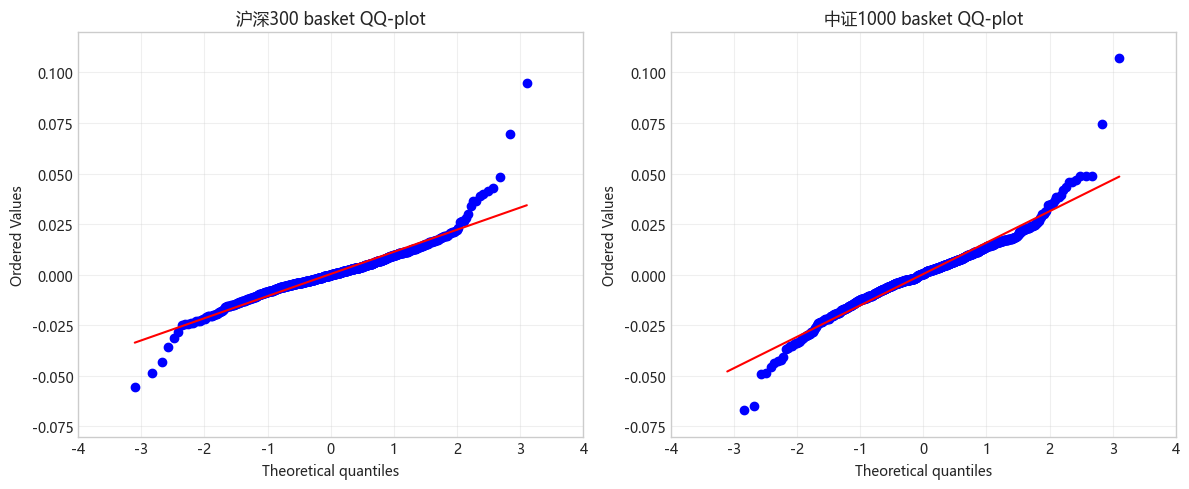

In [15]:
setup_chinese_font()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bins = np.linspace(-0.08, 0.12, 60)  # wide enough to capture stimulus day

for ax, (label, basket) in zip(axes, 
                               [('沪深300', hs300_basket), 
                                ('中证1000', zz1000_basket)]):
    ax.hist(basket, bins=bins, density=True, alpha=0.65, 
            color='steelblue', edgecolor='white', linewidth=0.5)
    
    # Overlay the normal distribution with matched mean and std
    x = np.linspace(bins.min(), bins.max(), 300)
    mu, sigma = basket.mean(), basket.std()
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=1.5, 
            label=f'Normal(μ={mu:.4f}, σ={sigma:.4f})')
    
    ax.set_title(f'{label} basket daily returns\n'
                 f'kurt={basket.kurtosis():.2f}, skew={basket.skew():.2f}')
    ax.set_xlabel('Daily return')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Density')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (label, basket) in zip(axes,
                               [('沪深300', hs300_basket),
                                ('中证1000', zz1000_basket)]):
    stats.probplot(basket, dist='norm', plot=ax)
    ax.set_title(f'{label} basket QQ-plot')
    ax.grid(alpha=0.3)

# Lock both axes to same limits
for ax in axes:
    ax.set_xlim(-4, 4)
    ax.set_ylim(-0.08, 0.12)

plt.tight_layout()
plt.show()

In [16]:
# Count limit-hit days per stock
def count_limit_hits(returns_matrix, label):
    # Main board limit: ±9.95% (use 9.95 not 10.00 to allow for rounding)
    # 创业板/科创板: ±19.90%
    main_board_hits = ((returns_matrix.abs() >= 0.0995) & 
                       (returns_matrix.abs() < 0.15)).sum().sum()
    cy_kc_hits = (returns_matrix.abs() >= 0.15).sum().sum()  # > 15% implies wider band
    
    print(f"{label}:")
    print(f"  Main-board limit hits (|r| >= 9.95%): {main_board_hits}")
    print(f"  Wider-band hits (|r| >= 15%):          {cy_kc_hits}")
    print(f"  Total stock-days: {returns_matrix.count().sum()}")

count_limit_hits(hs300_returns, '沪深300')
count_limit_hits(zz1000_returns, '中证1000')

沪深300:
  Main-board limit hits (|r| >= 9.95%): 85
  Wider-band hits (|r| >= 15%):          25
  Total stock-days: 18125
中证1000:
  Main-board limit hits (|r| >= 9.95%): 178
  Wider-band hits (|r| >= 15%):          22
  Total stock-days: 13050


In [17]:
# Find which stocks had wide-band hits
wide_band = (zz1000_returns.abs() >= 0.15)
stocks_with_wide_hits = wide_band.sum()
stocks_with_wide_hits = stocks_with_wide_hits[stocks_with_wide_hits > 0]
print("中证1000 stocks with |r| >= 15% days:")
print(stocks_with_wide_hits)
print(f"\nTheir codes: {list(stocks_with_wide_hits.index)}")

中证1000 stocks with |r| >= 15% days:
sz.300573    7
sh.688300    5
sz.301018    5
sz.301015    5
dtype: int64

Their codes: [np.str_('sz.300573'), np.str_('sh.688300'), np.str_('sz.301018'), np.str_('sz.301015')]


In [18]:
# 1. Predictions vs reality. What did you predict for each of std, kurt, skew, and same-date extremes? 
# For std I predicted the 中证1000 basket would have higher volatility than the 沪深300 basket, and this was confirmed from the higher daily and annualized std. 
# For kurt I predicted the 中证1000 basket would have higher kurtosis (fatter tails) than the 沪深300 basket, but this was not confirmed and it because kurtosis responds more actively to extreme outliers.
# For skew I predicted the 中证1000 basket would have negative skewness, whereas the 沪深300 basket would hover around zero, and this was confirmed.
# For same-date extremes I predicted the 中证1000 basket would have more extreme values on the same dates than the 沪深300 basket, and this was confirmed. This implies that baskets are not independent.
# The stimulus day was relatively more anomalous for the lower-vol 沪深300 basket, and 涨跌停 clipping compresses the measured small-cap tail.

# 2. Known biases in this analysis. 
# The IPO/listing date filter: stocks can be newly listed and have incomplete data points.
# Survivorship bias: stocks delisted between 2022 and today aren't in today's constituent list, so  worst performers are not in the sample at all.
# Inclusion bias: stocks added to the index between 2022 and today are in your sample because of strong recent performance. 
# IPO/filter bias:  2022-01-15 start cutoff dropped 7 stocks that IPO'd later. Unlike the first two, this one probably reduces upward bias  but narrows the 中证1000 basket toward older names.
# 涨跌停 individual-stock clipping: stocks that hit their daily limit are clipped at that point, which truncates the left tail
# Composition skew of the 中证1000 sample toward older main-board small-caps: this may lead to an overrepresentation of stocks with certain characteristics


# 3. Single-sentence headline for the 小盘股 thesis.
# In 2022-2024 sample with current constituents, 中证1000 basket shows higher std (24.8% vs 17.9%) and more negative skew (−0.28 vs 0.02 ex-stimulus) than 沪深300 basket, but lower measured kurtosis in both full and ex-stimulus samples. 
# Measured small-cap kurtosis is likely biased downward by 涨跌停 clipping and composition skew, so the true small-cap tail risk is probably underestimated here.
# So, any trading thesis that relies on betting on small-caps' volatility should account for extreme events and co-movements.

# 4. Your own core takeaway. 
# When I evaluate any strategy and backtest results, my first move will be to drop the best and worst quarters, then re-run the same statistic with the single largest observation removed.
# This is because statistics like Sharpe ratio are very sensitive to outliers, and a single quarter with a big stimulus or crash can make or break the story.


In [19]:
def calc_jb(N, skew, excess_kurt):
    JB = (N / 6) * (skew**2 + excess_kurt**2 / 4)
    return JB

print(calc_jb(N = 717, skew = +0.02, excess_kurt = 2.31))

print(calc_jb(N = 725, skew = +0.05, excess_kurt = 6.19))

print(calc_jb(N = 717, skew = -0.28, excess_kurt = 1.73))

159.4637875
1157.7676041666668
98.7816875


In [20]:
import os
os.makedirs('data', exist_ok=True)

series_to_save = {
    'basket_returns_hs300_full.csv':    hs300_basket,
    'basket_returns_hs300_exstim.csv':  hs300_ex,
    'basket_returns_zz1000_full.csv':   zz1000_basket,
    'basket_returns_zz1000_exstim.csv': zz1000_ex,
}

for filename, s in series_to_save.items():
    s.to_csv(f'data/{filename}', header=['return'])
    print(f"Saved {filename}: N = {len(s.dropna())}")

Saved basket_returns_hs300_full.csv: N = 725
Saved basket_returns_hs300_exstim.csv: N = 717
Saved basket_returns_zz1000_full.csv: N = 725
Saved basket_returns_zz1000_exstim.csv: N = 717
